In [1]:
import json
import pandas as pd
import zipfile
import os
import glob
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import numpy as np
import evaluate
from transformers import Trainer, TrainerCallback
from transformers.utils.notebook import NotebookProgressCallback
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report



zip_path = 'teenagers.corpus.zip'
extract_path = 'teenagers_data'
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

def load_subreddit_data(file_path, label):
    if not os.path.exists(file_path):
        return pd.DataFrame(columns=['text', 'label'])
        

    text_list = []
    with open(file_path, 'r') as f:
        try:
            data = json.load(f)
            if isinstance(data, dict):
                text_list = [v.get('text', '') for v in data.values() if v.get('text')]
            elif isinstance(data, list):
                text_list = [item.get('text', '') for item in data if item.get('text')]
        except json.JSONDecodeError:
            f.seek(0)
            for line in f:
                if line.strip():
                    item = json.loads(line)
                    text_list.append(item.get('text', ''))
    
    return pd.DataFrame({'text': text_list, 'label': label})



teen_files = glob.glob(f"{extract_path}/**/utterances.json*", recursive=True)
if not teen_files:
    teen_files = glob.glob(f"{extract_path}/**/*.json*", recursive=True)

df_phd =load_subreddit_data('utterances.jsonl', label=0)

if teen_files:
    print(f"Loading teenagers data from: {teen_files[0]}")
    df_teen = load_subreddit_data(teen_files[0], label=1)
else:
    df_teen = pd.DataFrame(columns=['text', 'label'])

df_final = pd.concat([df_phd, df_teen], ignore_index=True).sample(frac=1, random_state=42)


print(df_final.head(13))

Loading teenagers data from: teenagers_data/utterances.jsonl
                                                       text  label
10308595          There was one linked by sunny a while ago      1
11509523                                             Pizza       1
5680970                                           [deleted]      1
13688433                       Aubrey Plaza and Rahul Kohli      1
14767529  I don’t really believe in a casual relationshi...      1
1372296   Careful now, or you'll be getting reality show...      1
1750300   &gt; If kids weren't produced out of sex, I wo...      1
2417202   Be there for her, and like some one said, star...      1
804551                                                           1
9826608                                                Heys      1
4835396                             something with drawing       1
13352090                                              Damn.      1
14147068  Has anyone really been far even as decided to ...      1


In [2]:
# perf balance?
# teenager datas is huge, must take sample/subset to match phd
len(df_teen)

14947098

In [3]:
len(df_phd)

19443

In [4]:
with open('corpus.json', 'r') as f:
    stats = json.load(f)
    print(stats['num_comments'])

with open('conversations.json', 'r') as f:
    convos = json.load(f)
    print(len(convos))

 # utterance + number of 'conversation'


16516
2927


In [5]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

target_size = len(df_phd)
df_teen_balanced = df_teen.sample(n=target_size, random_state=42)
df_final = pd.concat([df_phd, df_teen_balanced]).reset_index(drop=True)
df_final = df_final[~df_final['text'].isin(['[deleted]', '[removed]', ''])]
df_final = df_final.dropna(subset=['text'])


def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=128
    )

hf_dataset = Dataset.from_pandas(df_final)
tokenized_dataset = hf_dataset.map(tokenize_function, batched=True)
sample = tokenized_dataset[0]
print(len(df_final))

#should add to 35k


Map:   0%|          | 0/35311 [00:00<?, ? examples/s]

35311


In [6]:
train_test = tokenized_dataset.train_test_split(test_size=0.2)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2
)

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3, #could adjust if still too long
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_test["train"],
    eval_dataset=train_test["test"],
    compute_metrics=compute_metrics,
)

trainer.train()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/racc/anaconda3/envs/nlp_bert/l

Epoch,Training Loss,Validation Loss,Accuracy
1,0.211542,0.220345,0.920855
2,0.130688,0.295529,0.917599
3,0.057929,0.350380,0.916749


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/racc/anaconda3/envs/nlp_bert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/racc/anaconda3/envs/nlp_bert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=5298, training_loss=0.16148954474642485, metrics={'train_runtime': 3144.9913, 'train_samples_per_second': 26.946, 'train_steps_per_second': 1.685, 'total_flos': 5574270818856960.0, 'train_loss': 0.16148954474642485, 'epoch': 3.0})

In [7]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_test["train"],
    eval_dataset=train_test["test"],
    compute_metrics=compute_metrics,
)

trainer.remove_callback(NotebookProgressCallback)
final_metrics = trainer.evaluate()

print(f"accuracy: {final_metrics['eval_accuracy']:.2%}")
print(f"loss: {final_metrics['eval_loss']:.4f}")

test_results = trainer.predict(train_test["test"])
predicted_labels = np.argmax(test_results.predictions, axis=-1)
true_labels = test_results.label_ids

df_test = pd.DataFrame({
    'text': train_test["test"]["text"],
    'actual': true_labels,
    'predicted': predicted_labels
})

mistakes = df_test[df_test['actual'] != df_test['predicted']]
print(f"num mistakes: {len(mistakes)} total utterances: {len(df_test)}")

if not mistakes.empty:
    row = mistakes.iloc[0]
    label_map = {0: "r/PhD", 1: "r/teenagers"}
    print(f"utterance: {row['text'][:200]}...")
    print(f"true: {label_map[row['actual']]}")
    print(f"predicted: {label_map[row['predicted']]}")

/Users/racc/anaconda3/envs/nlp_bert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


accuracy: 92.10%
loss: 0.2213


/Users/racc/anaconda3/envs/nlp_bert/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


num mistakes: 558 total utterances: 7063
utterance: Woah, now I feel special, providing advice for someone older than me.

And good luck!...
true: r/teenagers
predicted: r/PhD


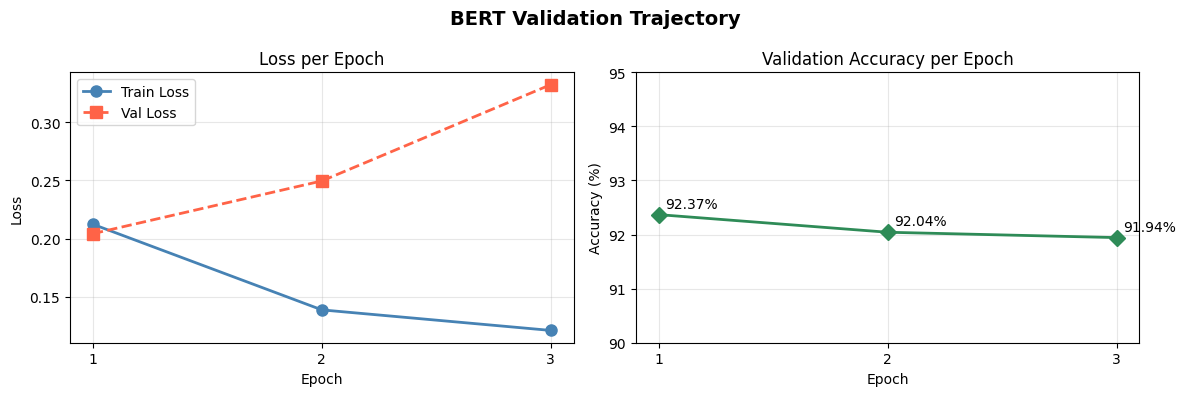

In [8]:
# line not displaying properly on 2nd graph
epochs = [1, 2, 3]
train_loss = [0.212236, 0.138726, 0.121079]
val_loss   = [0.204167, 0.249462, 0.332157]
val_acc    = [0.923687, 0.920430, 0.919439]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("BERT Validation Trajectory", fontsize=14, fontweight='bold')

ax1.plot(epochs, train_loss, 'o-', color='steelblue', label='Train Loss', linewidth=2, markersize=8)
ax1.plot(epochs, val_loss,   's--', color='tomato',    label='Val Loss',   linewidth=2, markersize=8)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss per Epoch"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs)

ax2.plot(epochs, [a * 100 for a in val_acc], 'D-', color='seagreen', linewidth=2, markersize=8)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Validation Accuracy per Epoch")
ax2.set_ylim(90, 95); ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs)
for i, (ep, acc) in enumerate(zip(epochs, val_acc)):
    ax2.annotate(f"{acc:.2%}", (ep, acc * 100), textcoords="offset points", xytext=(5, 5))

plt.tight_layout()



plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

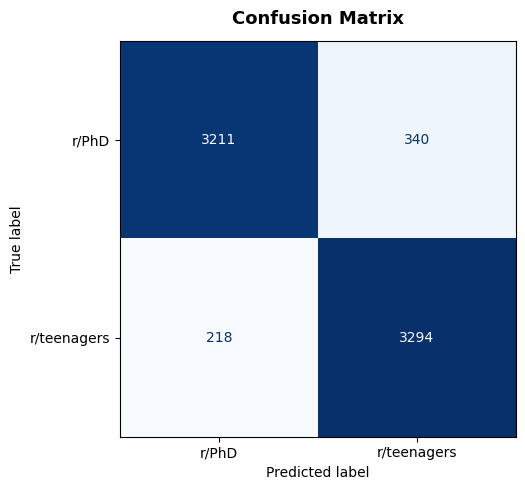

r/PhD: 3211/3551 correct (90.43%)
r/teenagers: 3294/3512 correct (93.79%)


In [9]:
cm = confusion_matrix(true_labels, predicted_labels)

labels = ["r/PhD", "r/teenagers"]
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion Matrix", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

for i, label in enumerate(labels):
    tp = cm[i, i]
    total = cm[i].sum()
    print(f"{label}: {tp}/{total} correct ({tp/total:.2%})")

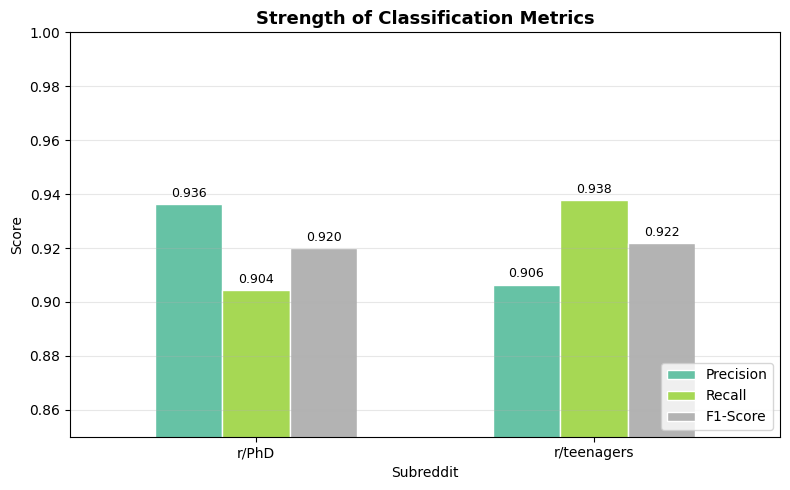

In [10]:
report = classification_report(true_labels, predicted_labels,
                               target_names=["r/PhD", "r/teenagers"],
                               output_dict=True)

df_report = pd.DataFrame(report).T.loc[["r/PhD", "r/teenagers"], ["precision", "recall", "f1-score"]]
df_report.columns = ["Precision", "Recall", "F1-Score"]

ax = df_report.plot(kind='bar', figsize=(8, 5), colormap='Set2', edgecolor='white', width=0.6)
ax.set_title("Strength of Classification Metrics", fontsize=13, fontweight='bold')
ax.set_xlabel("Subreddit"); ax.set_ylabel("Score")
ax.set_ylim(0.85, 1.0)
ax.set_xticklabels(["r/PhD", "r/teenagers"], rotation=0)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)


for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()

plt.savefig("classification_report.png", dpi=150, bbox_inches='tight')
plt.show()


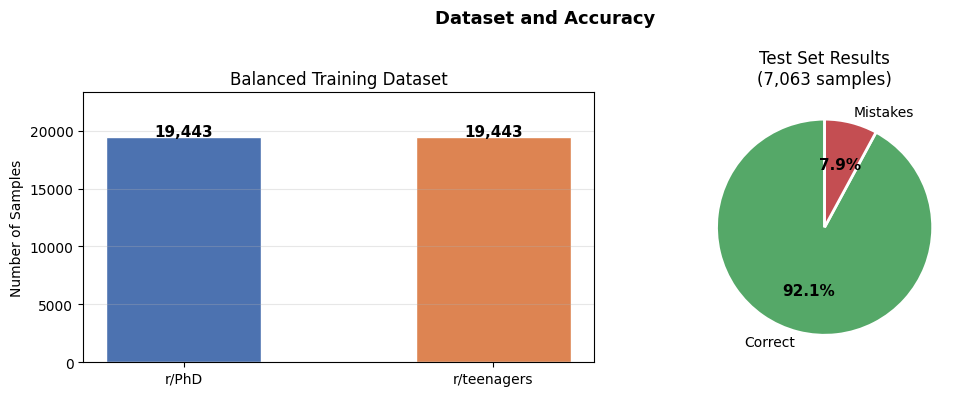

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Dataset and Accuracy", fontsize=13, fontweight='bold')

counts = [len(df_phd), len(df_teen_balanced)]
labels = ["r/PhD", "r/teenagers"]
colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', width=0.5)
axes[0].set_title("Balanced Training Dataset")
axes[0].set_ylabel("Number of Samples")
axes[0].set_ylim(0, max(counts) * 1.2)
axes[0].grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{count:,}", ha='center', fontsize=11, fontweight='bold')

total_test = len(df_test)
n_mistakes = len(mistakes)
n_correct  = total_test - n_mistakes

wedges, texts, autotexts = axes[1].pie(
    [n_correct, n_mistakes],
    labels=["Correct", "Mistakes"],
    autopct='%1.1f%%',
    colors=['#55a868', '#c44e52'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
axes[1].set_title(f"Test Set Results\n({total_test:,} samples)")

plt.tight_layout()
plt.savefig("dataset_analysis.png", dpi=150, bbox_inches='tight')

plt.show()
